In [1]:
import cv2
import matplotlib.pyplot as plt

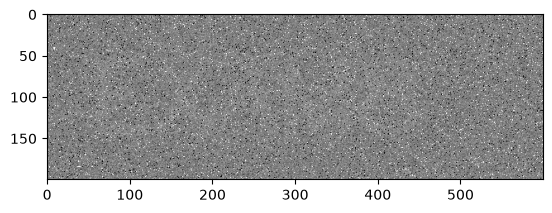

In [2]:
image = cv2.imread('noisy_image.png', 0)
plt.imshow(image, cmap='gray')

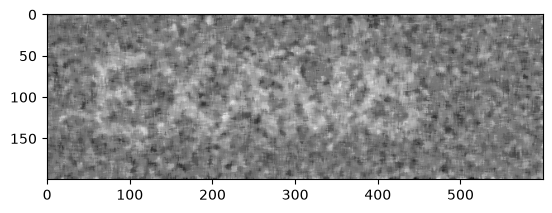

In [3]:
# the median filter removes isolated black and white pixels (salt and pepper)
image_median = cv2.medianBlur(image, 7)
plt.imshow(image_median, cmap='gray')

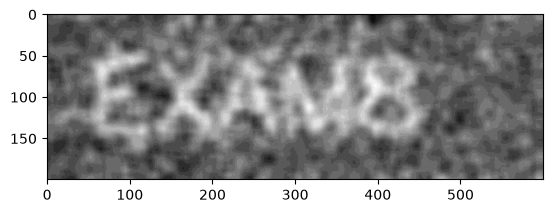

In [4]:
# the mean filter removes the remaining gaussian noise
image_moyenne = cv2.blur(image_median, (15, 15))
plt.imshow(image_moyenne, cmap='gray')

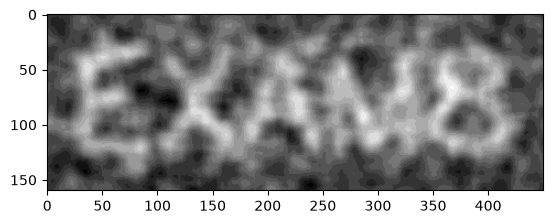

In [5]:
# we can see where the text is, so we crop around it
zone = image_moyenne[20:180, 30:480]
plt.imshow(zone, cmap='gray')

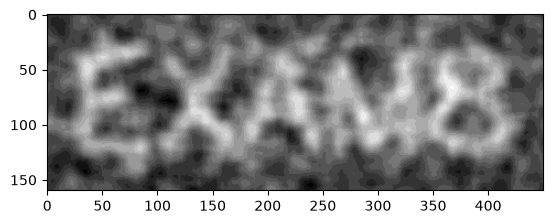

In [6]:
# the text is barely lighter than the background, so we stretch the contrast
zone_contraste = cv2.normalize(zone, None, 0, 255, cv2.NORM_MINMAX)
plt.imshow(zone_contraste, cmap='gray')

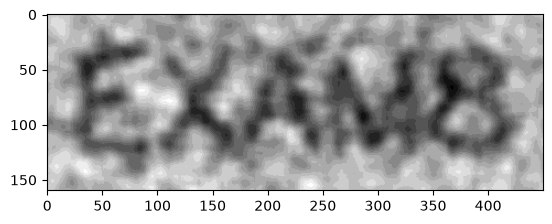

In [7]:
# dark text on a light background
image_finale = cv2.bitwise_not(zone_contraste)
plt.imshow(image_finale, cmap='gray')

In [8]:
cv2.imwrite('figure_cleaned.png', image_finale)

True

In [9]:
import os
os.environ['FLAGS_use_mkldnn'] = '0'

from paddleocr import PaddleOCR
ocr = PaddleOCR(lang='en',
                enable_mkldnn=False,
                use_doc_orientation_classify=False,
                use_doc_unwarping=False,
                use_textline_orientation=False)

C:\Users\nmeds\AppData\Local\Programs\Python\Python311\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Creating model: ('PP-OCRv6_medium_det', None, None)


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\nmeds\.paddlex\official_models\PP-OCRv6_medium_det`.


Creating model: ('PP-OCRv6_medium_rec', None, None)


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\nmeds\.paddlex\official_models\PP-OCRv6_medium_rec`.


In [10]:
resultat = ocr.predict('figure_cleaned.png')

for res in resultat:
    print(res['rec_texts'], res['rec_scores'])

['EXAM8'] [0.9908405542373657]
